# Week 5 Day 3
# Feature Engineering on Stock Data

## Objective

Create technical indicators from Reliance stock prices:

- SMA(20)
- SMA(50)
- EMA(12)
- EMA(26)
- MACD
- RSI(14)
- Bollinger Bands

These indicators help identify trends, momentum, and volatility.

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf

import matplotlib.pyplot as plt

plt.style.use("default")

In [2]:
reliance = yf.download(
    "RELIANCE.NS",
    start="2020-01-01",
    end="2025-01-01",
    auto_adjust=True
)

# keep only first level column names
reliance.columns = reliance.columns.get_level_values(0)

[*********************100%***********************]  1 of 1 completed


In [3]:
reliance.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1238 entries, 2020-01-01 to 2024-12-31
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   1238 non-null   float64
 1   High    1238 non-null   float64
 2   Low     1238 non-null   float64
 3   Open    1238 non-null   float64
 4   Volume  1238 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 58.0 KB


## Simple Moving Averages (SMA)

SMA calculates the average closing price over a fixed window.

- SMA(20) = short-term trend
- SMA(50) = medium-term trend

In [4]:
reliance["SMA20"] = (
    reliance["Close"]
    .rolling(window=20)
    .mean()
)

reliance["SMA50"] = (
    reliance["Close"]
    .rolling(window=50)
    .mean()
)

## Exponential Moving Average (EMA)

EMA gives more weight to recent prices.

- EMA(12)
- EMA(26)

In [5]:
reliance["EMA12"] = (
    reliance["Close"]
    .ewm(span=12, adjust=False)
    .mean()
)

reliance["EMA26"] = (
    reliance["Close"]
    .ewm(span=26, adjust=False)
    .mean()
)

## MACD

MACD = EMA12 − EMA26

Used to identify momentum and trend changes.

In [6]:
reliance["MACD"] = (
    reliance["EMA12"]
    - reliance["EMA26"]
)

reliance["Signal"] = (
    reliance["MACD"]
    .ewm(span=9, adjust=False)
    .mean()
)

## RSI (Relative Strength Index)

RSI measures momentum.

Interpretation:

- Above 70 → Overbought
- Below 30 → Oversold

In [7]:
delta = reliance["Close"].diff()

gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)

avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()

rs = avg_gain / avg_loss

reliance["RSI"] = (
    100 - (100 / (1 + rs))
)

## Bollinger Bands

Bollinger Bands use a moving average and standard deviation.

Upper Band = SMA20 + 2 × Std

Lower Band = SMA20 − 2 × Std

In [8]:
rolling_std = (
    reliance["Close"]
    .rolling(20)
    .std()
)

reliance["Upper_Band"] = (
    reliance["SMA20"]
    + 2 * rolling_std
)

reliance["Lower_Band"] = (
    reliance["SMA20"]
    - 2 * rolling_std
)

In [9]:
print(reliance.columns)

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'SMA20', 'SMA50', 'EMA12',
       'EMA26', 'MACD', 'Signal', 'RSI', 'Upper_Band', 'Lower_Band'],
      dtype='object', name='Price')


In [10]:
reliance[
    [
        "Close",
        "SMA20",
        "SMA50",
        "EMA12",
        "EMA26",
        "MACD",
        "RSI",
        "Upper_Band",
        "Lower_Band"
    ]
].tail()

Price,Close,SMA20,SMA50,EMA12,EMA26,MACD,RSI,Upper_Band,Lower_Band
Date,,,,,,,,,
2024-12-24,1212.280884,1262.735083,1285.481133,1237.190638,1259.293772,-22.103134,26.460939,1332.058950,1193.411216
2024-12-26,1206.133911,1258.935400,1282.388342,1232.412680,1255.356005,-22.943325,20.062359,1332.012743,1185.858058
2024-12-27,1210.595459,1256.469202,1279.949902,1229.056185,1252.040409,-22.984224,23.413593,1332.669153,1180.269251
2024-12-30,1200.333862,1252.429089,1277.106953,1224.637366,1248.210294,-23.572929,24.276516,1331.631461,1173.226718
2024-12-31,1205.043213,1247.784198,1274.311592,1221.622881,1245.012733,-23.389852,28.121029,1326.643710,1168.924686


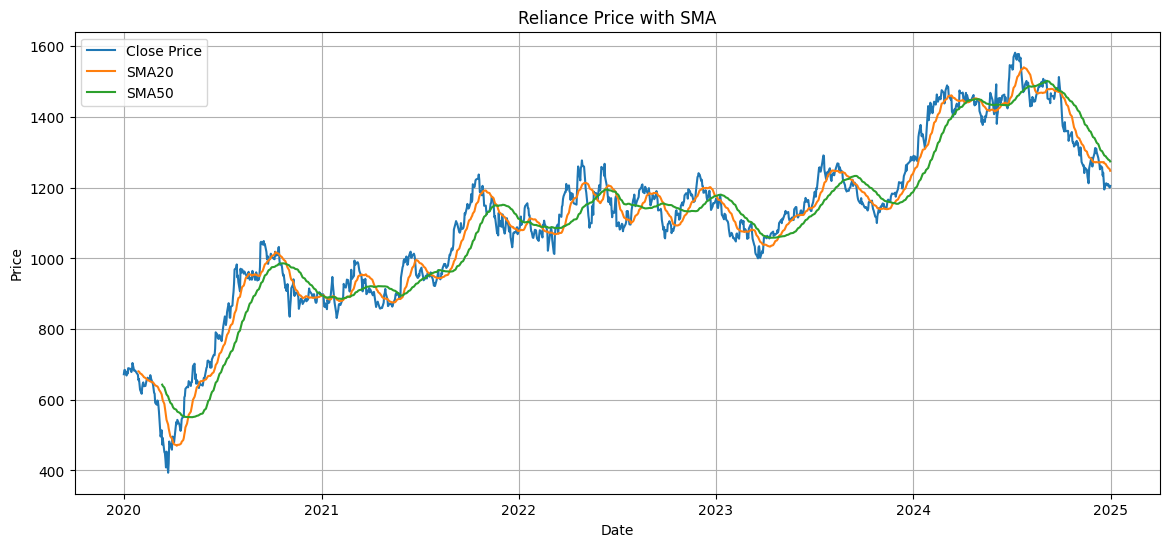

In [11]:
plt.figure(figsize=(14,6))

plt.plot(
    reliance.index,
    reliance["Close"],
    label="Close Price"
)

plt.plot(
    reliance.index,
    reliance["SMA20"],
    label="SMA20"
)

plt.plot(
    reliance.index,
    reliance["SMA50"],
    label="SMA50"
)

plt.title("Reliance Price with SMA")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)

plt.show()

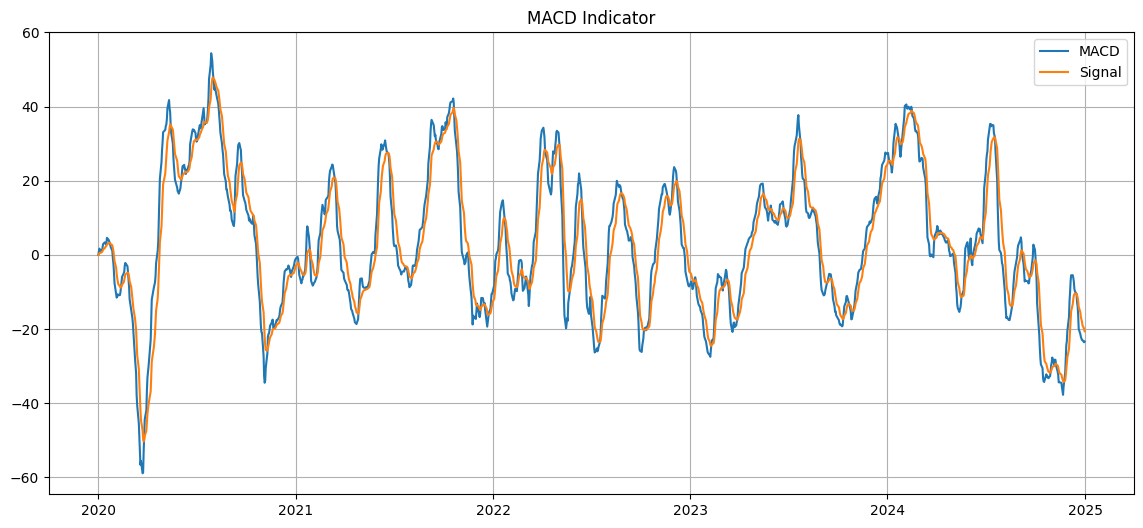

In [12]:
plt.figure(figsize=(14,6))

plt.plot(
    reliance.index,
    reliance["MACD"],
    label="MACD"
)

plt.plot(
    reliance.index,
    reliance["Signal"],
    label="Signal"
)

plt.title("MACD Indicator")
plt.legend()
plt.grid(True)

plt.show()


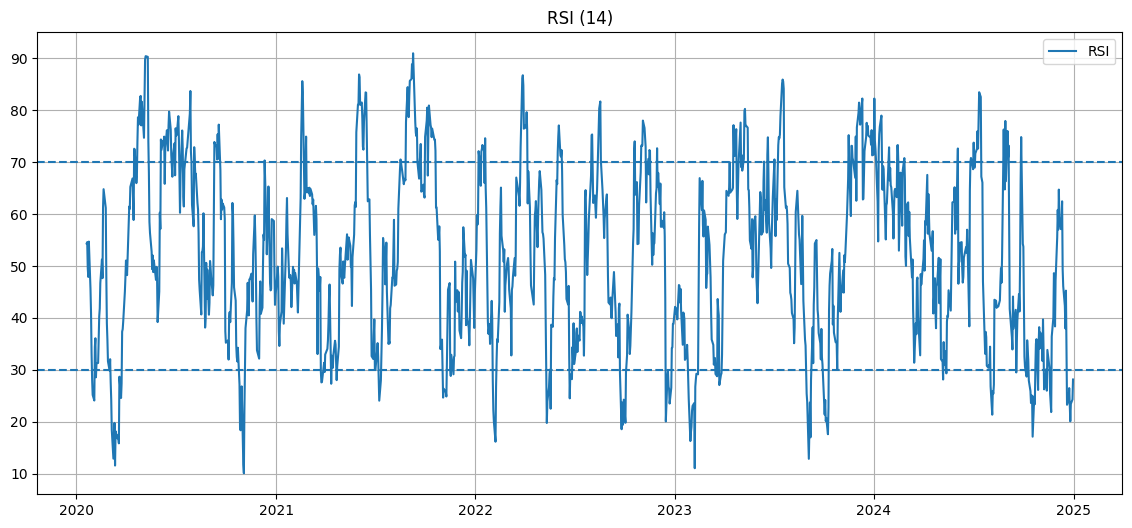

In [13]:
plt.figure(figsize=(14,6))

plt.plot(
    reliance.index,
    reliance["RSI"],
    label="RSI"
)

plt.axhline(
    70,
    linestyle="--"
)

plt.axhline(
    30,
    linestyle="--"
)

plt.title("RSI (14)")
plt.legend()
plt.grid(True)

plt.show()


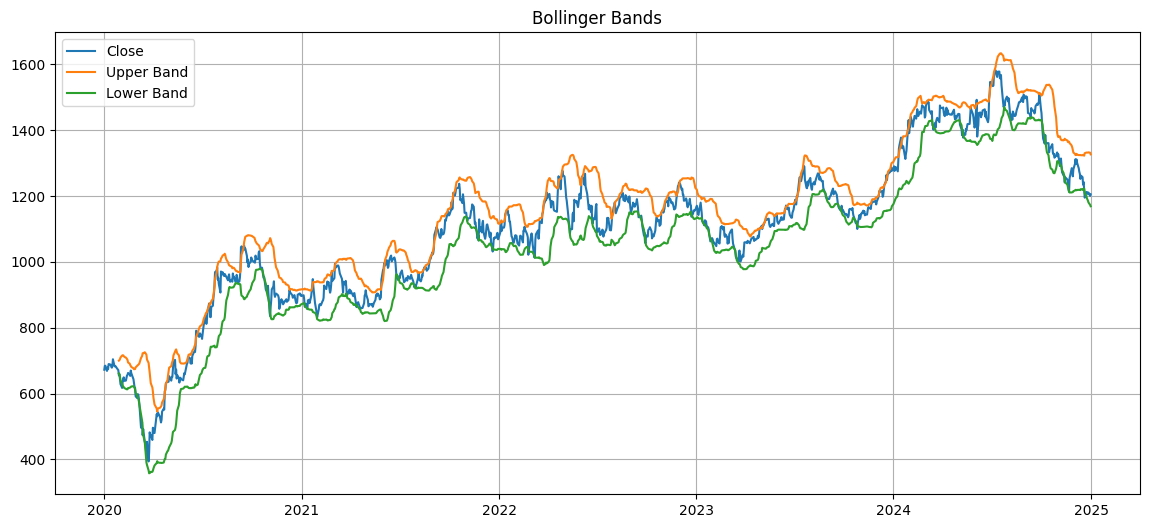

In [14]:
plt.figure(figsize=(14,6))

plt.plot(
    reliance.index,
    reliance["Close"],
    label="Close"
)

plt.plot(
    reliance.index,
    reliance["Upper_Band"],
    label="Upper Band"
)

plt.plot(
    reliance.index,
    reliance["Lower_Band"],
    label="Lower Band"
)

plt.title("Bollinger Bands")
plt.legend()
plt.grid(True)

plt.show()


In [15]:
plt.savefig("../images/price_ma.png", dpi=300)

<Figure size 640x480 with 0 Axes>

In [16]:
plt.savefig("../images/macd.png", dpi=300)

<Figure size 640x480 with 0 Axes>

In [17]:
plt.savefig("../images/rsi_bollinger.png", dpi=300)

<Figure size 640x480 with 0 Axes>

## Observations

1. SMA20 reacts faster to price changes than SMA50.
2. EMA indicators respond more quickly than SMA.
3. MACD crossed above and below the signal line multiple times, indicating momentum shifts.
4. RSI frequently moved between 30 and 70, showing periods of oversold and overbought conditions.
5. Bollinger Bands widened during volatile periods and narrowed during stable periods.